In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv('spam.csv', encoding='latin-1')
df.sample(5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3059,ham,K..k...from tomorrow onwards started ah?,NaN,NaN,NaN
4333,ham,Boo what time u get out? U were supposed to ta...,NaN,NaN,NaN
1130,ham,Howz pain?hope u r fine..,NaN,NaN,NaN
1552,ham,U too...,NaN,NaN,NaN
5118,ham,Are you driving or training?,NaN,NaN,NaN


In [2]:
df.shape

(5572, 5)

# DATA CLEANING

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [5]:
df.sample(5)

,v1,v2
3055,ham,Webpage s not available!
884,ham,Yoyyooo u know how to change permissions for a...
5264,ham,"Storming msg: Wen u lift d phne, u say \HELLO\..."
2287,ham,Alex knows a guy who sells mids but he's down ...
1247,ham,Horrible gal. Me in sch doing some stuff. How ...


In [6]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
2391,ham,PICK UR FONE UP NOW U DUMB?
3397,ham,It only does simple arithmetic not percentages.
1414,ham,So wats ur opinion abt him and how abt is char...
5148,ham,K..then come wenever u lik to come and also te...
370,ham,Hello my boytoy ... Geeee I miss you already a...


In [7]:
from sklearn.preprocessing import LabelEncoder #imports LabelEncoder from the sklearn (Scikit-learn)Python library used for machine learning tasks.
encoder = LabelEncoder() #create an object (instance) of the LabelEncoder class.convert categorical labels into numerical values.
df['target'] = encoder.fit_transform(df['target']) #It scans the target column.Finds all unique categories.Assigns a number to each category.

In [8]:
df.isnull().sum() # check missing values

target    0
text      0
dtype: int64

In [9]:
df.duplicated().sum() # check if duplicate values in data

np.int64(403)

In [10]:
df = df.drop_duplicates(keep='first') # remove duplicates

# EDA

In [11]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

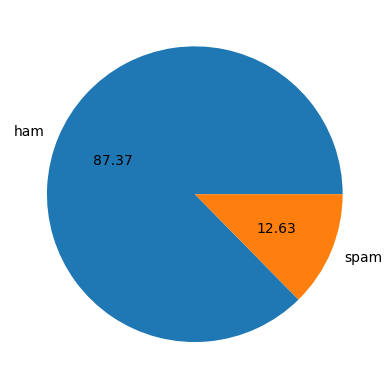

In [13]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct = "%0.2f")
plt.show()

In [14]:
#data is implaced

In [15]:
import nltk

In [16]:
!pip install nltk

In [17]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
df['numberof_character'] = df['text'].apply(len)

In [19]:
df.head()

,target,text,numberof_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [20]:
#number of words
df['num_of_word'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [21]:
df['num_of_sentence'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [22]:
df.head()

,target,text,numberof_character,num_of_word,num_of_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [23]:
df[['numberof_character','num_of_word','num_of_sentence']].describe()

,numberof_character,num_of_word,num_of_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
df[df['target'] == 0][['numberof_character','num_of_word','num_of_sentence']].describe() #ham

,numberof_character,num_of_word,num_of_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
df[df['target'] == 1][['numberof_character','num_of_word','num_of_sentence']].describe() #spam

,numberof_character,num_of_word,num_of_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [26]:
import seaborn as sb


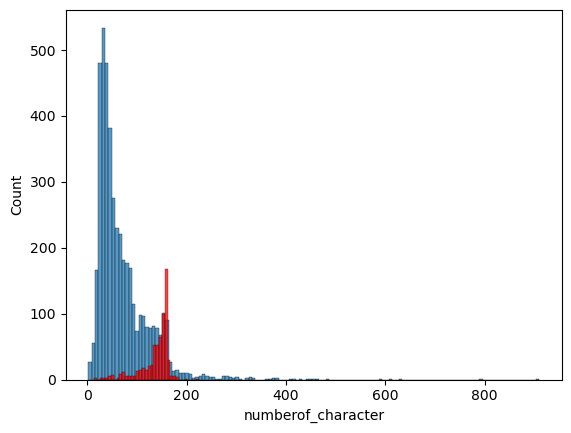

In [27]:
sb.histplot(df[df['target'] == 0]['numberof_character']) #histogram for ham msg
sb.histplot(df[df['target'] == 1]['numberof_character'],color = 'red') #histogram for spam msg
plt.show()

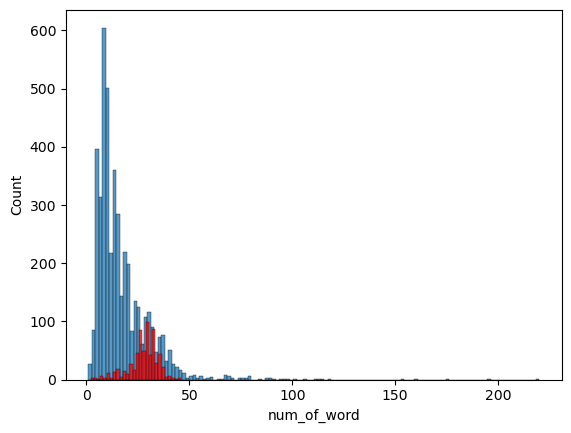

In [28]:
sb.histplot(df[df['target'] == 0]['num_of_word']) #histogram for ham msg
sb.histplot(df[df['target'] == 1]['num_of_word'],color = 'red') #histogram for spam msg
plt.show()

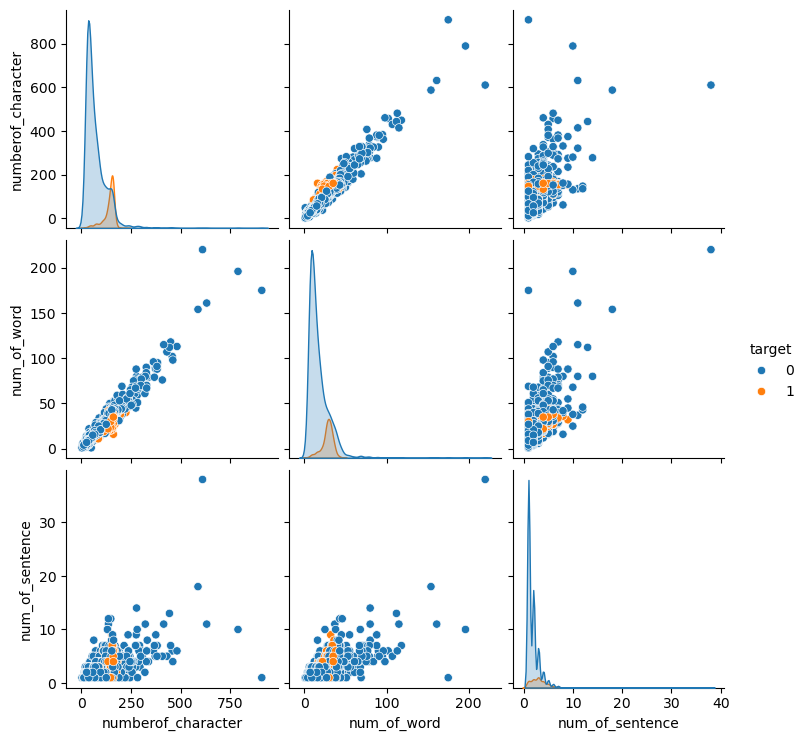

In [29]:
sb.pairplot(df,hue='target')
plt.show()

In [30]:
# data has outliers , less linear


<Axes: >

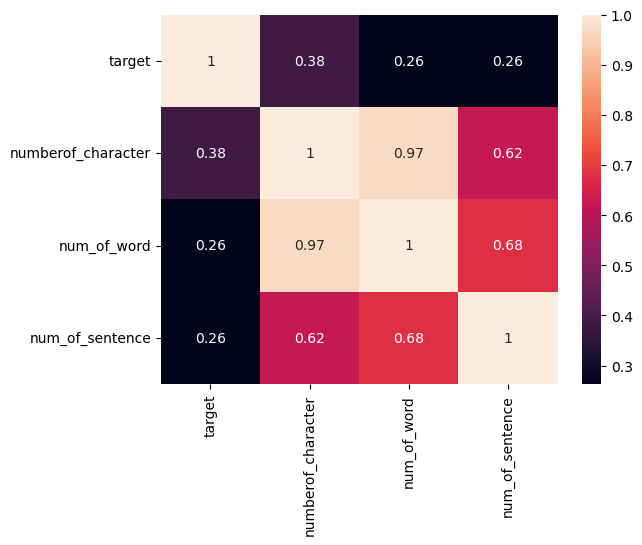

In [31]:
# First, filter only the numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Then create the heatmap with proper capitalization of True
sb.heatmap(numeric_df.corr(), annot=True)

# Alternative approach if you need to work with specific columns:
# sb.heatmap(df[['numeric_col1', 'numeric_col2', 'numeric_col3']].corr(), annot=True)

In [32]:
# for model we can take only one parameter  as all three columns has strong corelation and thats num_character as it shows highest variance with the target column

# 3. Data Preprocessing
   . Lower Case
   . Tokenization
   . Removing Special Characters
   . Removing stop words and punctuations
   . Stemming  

In [33]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y.copy() # cloning of list so changes does not affect the original list  
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:   # stopwords doesnot have specific meaning in english
            y.append(i)
    text = y.copy() # cloning of list so changes does not affect the original list  
    y.clear()
        
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [34]:

nltk.download('stopwords') #dowload stopword resources
from nltk.corpus import stopwords
stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [35]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [36]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [37]:
df['transformed_text'] = df['text'].apply(transform_text)

In [38]:
transform_text('how are you doing neha? do you still like dancing')

'neha still like danc'

In [39]:
df.head()

,target,text,numberof_character,num_of_word,num_of_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [40]:
# word cloud spam msg
!pip install wordcloud
from wordcloud import WordCloud  # Corrected from WorldCloud to WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')

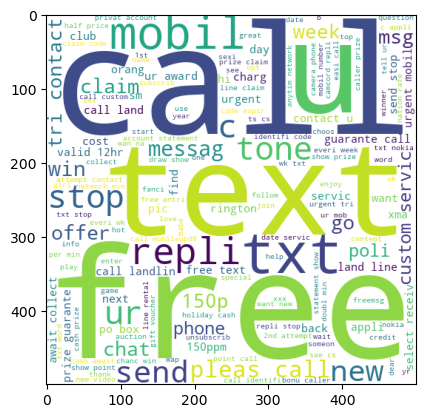

In [41]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

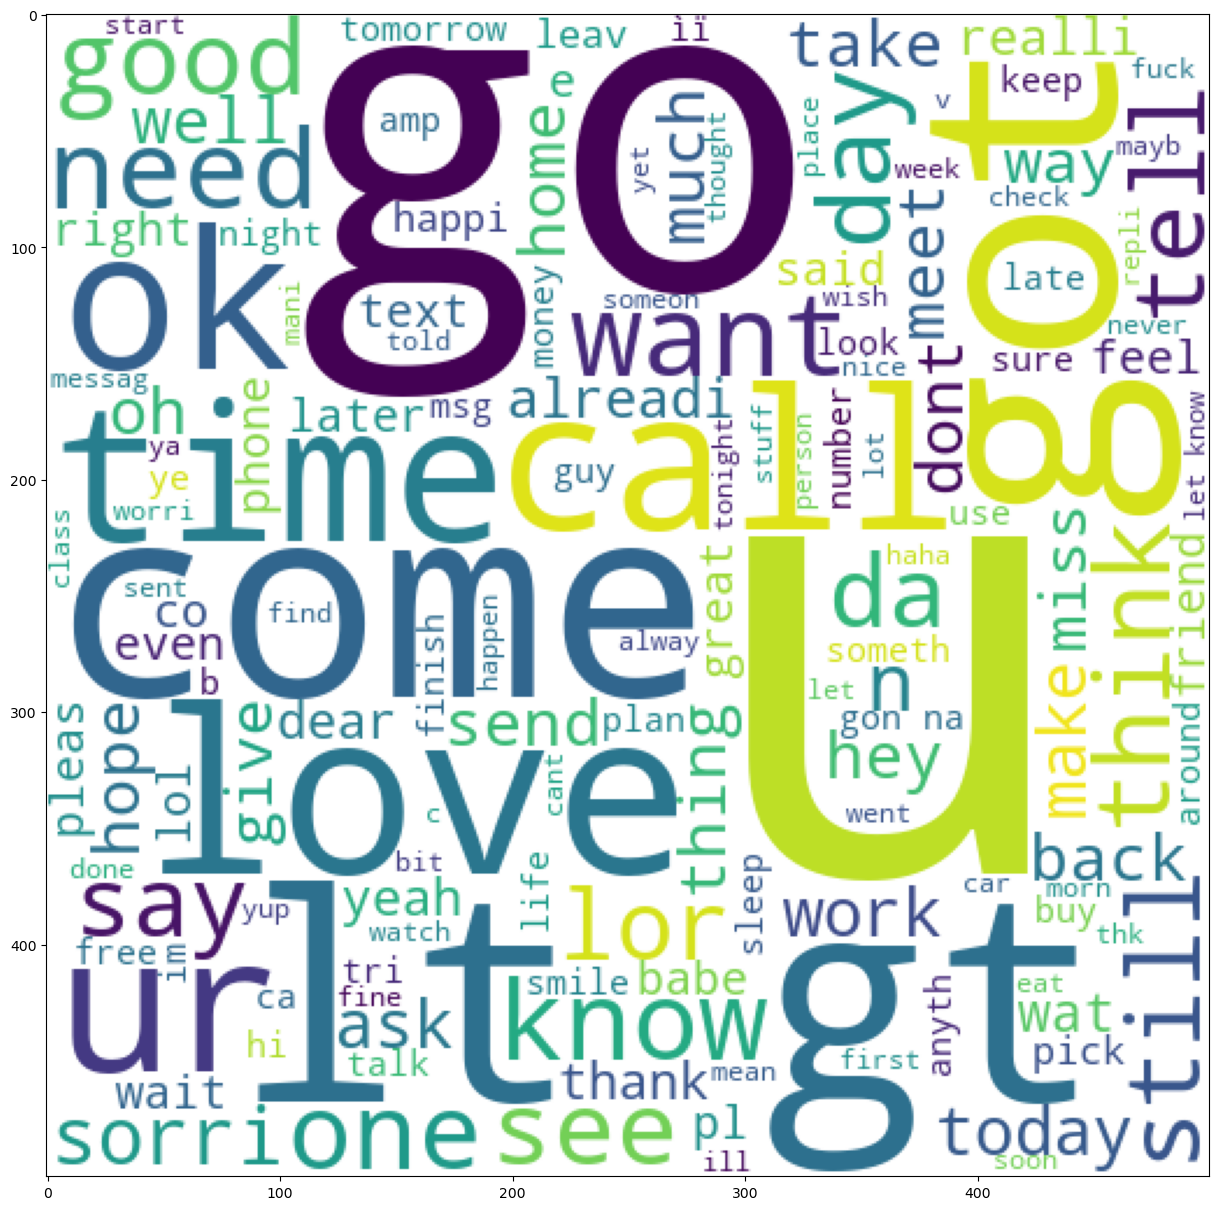

In [42]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize = (15,16))
plt.imshow(ham_wc)

 # 4. Model Building

In [43]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [44]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [45]:
X.shape

(5169, 6708)

In [46]:
y = df['target'].values

In [47]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2) # data for training is 20%

In [50]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [51]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [52]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [53]:
mnb.fit(X_train,y_train)
y_pred1 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [54]:
bnb.fit(X_train,y_train)
y_pred1 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [55]:
# TFIDF --> MNB AS the precision score is highest the accuracy of spam detection is highest

In [56]:
# Install XGBoost library (used for advanced gradient boosting algorithm)
!pip install xgboost  

# Import Logistic Regression model (used for binary classification problems)
from sklearn.linear_model import LogisticRegression  

# Import Support Vector Classifier (used to find optimal decision boundary)
from sklearn.svm import SVC  

# Import Multinomial Naive Bayes (commonly used for text classification)
from sklearn.naive_bayes import MultinomialNB  

# Import Decision Tree Classifier (tree-based model for classification)
from sklearn.tree import DecisionTreeClassifier  

# Import K-Nearest Neighbors (classifies based on nearest data points)
from sklearn.neighbors import KNeighborsClassifier  

# Import Random Forest (ensemble of multiple decision trees to reduce overfitting)
from sklearn.ensemble import RandomForestClassifier  

# Import AdaBoost (boosting algorithm that improves weak learners)
from sklearn.ensemble import AdaBoostClassifier  

# Import Bagging Classifier (reduces variance using bootstrap sampling)
from sklearn.ensemble import BaggingClassifier  

# Import Extra Trees Classifier (similar to Random Forest but with more randomness)
from sklearn.ensemble import ExtraTreesClassifier  

# Import Gradient Boosting Classifier (builds models sequentially to reduce errors)
from sklearn.ensemble import GradientBoostingClassifier  

# Import XGBoost Classifier (optimized and powerful gradient boosting algorithm)
from xgboost import XGBClassifier  

In [57]:
svc = SVC(kernel = 'sigmoid', gamma = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver = 'liblinear',penalty = '11')
rfc = RandomForestClassifier(n_estimators = 50,random_state=2)
abc = AdaBoostClassifier(n_estimators = 50,random_state=2)
bc = BaggingClassifier(n_estimators = 50,random_state=2)
etc = ExtraTreesClassifier(n_estimators = 50,random_state=2)
gbdt = GradientBoostingClassifier(n_estimators = 50,random_state=2)
xgb = XGBClassifier(n_estimators = 50,random_state=2)  
# basic hyper parameter tunning

In [58]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC' : bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb' : xgb
}

In [59]:
def train_classifier(clf,X_train,y_train,X_test,y_test): #parameters are classifier(clf),training and testing dataset
    clf.fit(X_train,y_train)  # classifier is being  trained on training datset  
    y_predict = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_predict)
    precision = precision_score(y_test,y_predict)

    return accuracy,precision
    

In [60]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9729206963249516, 0.9741379310344828)

In [60]:
train_classifier(knc,X_train,y_train,X_test,y_test)

(0.9003868471953579, 1.0)

In [62]:
train_classifier(mnb,X_train, y_train,X_test,y_test)
mnb.fit(X_train, y_train)

MultinomialNB()

In [63]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [64]:
test = tfidf.transform(["free money win now"])
print(mnb.predict(test))

[0]
